In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
from torchsummary import summary


import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transforms.ToTensor())
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(train_data.data.shape)
print(train_data.classes)

Files already downloaded and verified
Files already downloaded and verified
(50000, 32, 32, 3)
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [ ]:
import torch.nn.functional as F

class InceptionModule(nn.Module):
    """
    Inception Module implementation inspired by the original GoogleNet paper.

    Parameters:
        in_channels (int): Number of input channels.
        c1 (int): Number of filters for the 1x1 convolution branch.
        c3_red (int): Number of filters for the 1x1 convolution before the 3x3 convolution.
        c3 (int): Number of filters for the 3x3 convolution.
        c5_red (int): Number of filters for the 1x1 convolution before the 5x5 convolution.
        c5 (int): Number of filters for the 5x5 convolution.
        pool_proj (int): Number of filters for the 1x1 convolution after the pooling operation.
    """
    def __init__(self, in_channels, c1, c3_red, c3, c5_red, c5, pool_proj):
        super(InceptionModule, self).__init__()
        # Branch 1: Simple 1x1 convolution
        self.branch1 = nn.Conv2d(in_channels, c1, kernel_size=1)

        # Branch 2: 1x1 convolution followed by a 3x3 convolution
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, c3_red, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(c3_red, c3, kernel_size=3, padding=1)
        )
        
        nn.Re

        # Branch 3: 1x1 convolution followed by a 5x5 convolution
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, c5_red, kernel_size=1),
            nn.ReLU(),
            nn.Conv2d(c5_red, c5, kernel_size=5, padding=2)
        )

        # Branch 4: 3x3 pooling followed by a 1x1 convolution
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1)
        )

    def forward(self, x):
        branch1 = F.relu(self.branch1(x))
        branch2 = F.relu(self.branch2(x))
        branch3 = F.relu(self.branch3(x))
        branch4 = F.relu(self.branch4(x))

        # Concatenate the outputs along the channel dimension
        return torch.cat([branch1, branch2, branch3, branch4], 1)


class SmallGoogLeNet(nn.Module):
    """
    A simplified version of the GoogleNet architecture tailored for smaller datasets like CIFAR-10.

    Parameters:
        num_classes (int): Number of output classes.
    """
    def __init__(self, num_classes=10):
        super(SmallGoogLeNet, self).__init__()

        # Initial convolution layer
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2, stride=2)

        # Two sequential Inception modules
        self.inception1 = InceptionModule(in_channels=32, c1=16, c3_red=16, c3=24, c5_red=4, c5=8, pool_proj=8)
        self.inception2 = InceptionModule(in_channels=56, c1=32, c3_red=24, c3=32, c5_red=8, c5=16, pool_proj=16)

        # Adaptive average pooling and final fully connected layer
        self.pool2 = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(96, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))    # [batch, 32, 32, 32]
        x = self.pool1(x)            # [batch, 32, 16, 16]

        x = self.inception1(x)       # [batch, 56, 16, 16]
        x = self.inception2(x)       # [batch, 96, 16, 16]

        x = self.pool2(x)            # [batch, 96, 1, 1]
        x = x.view(x.size(0), -1)    # Flatten feature maps
        x = self.dropout(x)
        x = self.fc(x)

        return x

# Example usage:
model = SmallGoogLeNet(num_classes=10)
model.to(device)

model

SmallGoogLeNet(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (inception1): InceptionModule(
    (branch1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1))
    (branch2): Sequential(
      (0): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU()
      (2): Conv2d(16, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
    (branch3): Sequential(
      (0): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
      (1): ReLU()
      (2): Conv2d(4, 8, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    )
    (branch4): Sequential(
      (0): MaxPool2d(kernel_size=3, stride=1, padding=1, dilation=1, ceil_mode=False)
      (1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (inception2): InceptionModule(
    (branch1): Conv2d(56, 32, kernel_size=(1, 1), stride=(1, 1))
    (branch2): Sequential(
      (0): Conv2d(56, 24, kernel_size=(1,

In [13]:
summary(model, (3, 32, 32), device=str(device), batch_size=64)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [64, 32, 32, 32]             896
         MaxPool2d-2           [64, 32, 16, 16]               0
            Conv2d-3           [64, 16, 16, 16]             528
            Conv2d-4           [64, 16, 16, 16]             528
              ReLU-5           [64, 16, 16, 16]               0
            Conv2d-6           [64, 24, 16, 16]           3,480
            Conv2d-7            [64, 4, 16, 16]             132
              ReLU-8            [64, 4, 16, 16]               0
            Conv2d-9            [64, 8, 16, 16]             808
        MaxPool2d-10           [64, 32, 16, 16]               0
           Conv2d-11            [64, 8, 16, 16]             264
  InceptionModule-12           [64, 56, 16, 16]               0
           Conv2d-13           [64, 32, 16, 16]           1,824
           Conv2d-14           [64, 24,

In [ ]:
def get_output_size(W, kernel_size, stride, padding, num_filters, H=None):
    if H is None:
        H = W
    w_out = (W - kernel_size + 2 * padding) // stride + 1
    h_out = (W - kernel_size + 2 * padding) // stride + 1
    print((w_out, h_out, num_filters))

get_output_size(64, kernel_size=1, stride=1, padding=0, num_filters=128)     # Conv2d
get_output_size(128, kernel_size=3, stride=1, padding=1, num_filters=256)    # Conv2d
get_output_size(256, kernel_size=5, stride=1, padding=2, num_filters=512)     # Conv2d


(28, 28, 64)
(28, 28, 128)
(28, 28, 32)


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,                 # Adam default is 1e-3
    betas=(0.9, 0.999),      # default momentum terms
    eps=1e-8,                # numerical stability term
    weight_decay=1e-4        # L2 regularization, if you still want it
)

In [7]:
from IPython.display import clear_output
import matplotlib.pyplot as plt

def train_and_plot_inline(model, train_loader, test_loader, train_data, test_data, device, epochs=20):
    """
    Trains the model and updates inline charts at each epoch 
    showing train vs test loss and accuracy with grid lines and markers.
    """
    # Lists to store metrics
    epochs_list = []
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    for epoch in range(1, epochs + 1):
        # Before you start training/testing
        torch.cuda.reset_peak_memory_stats(device)   # clear previous stats

        # Train
        model.train()
        total_loss, correct = 0.0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct += (outputs.argmax(dim=1) == labels).sum().item()
        avg_train_loss = total_loss / len(train_loader)
        train_acc = correct / len(train_data)

        # Test
        model.eval()
        with torch.no_grad():
            total_loss, correct = 0.0, 0
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                total_loss += loss.item()
                correct += (outputs.argmax(dim=1) == labels).sum().item()
            avg_test_loss = total_loss / len(test_loader)
            test_acc = correct / len(test_data)

        # Record
        epochs_list.append(epoch)
        train_losses.append(avg_train_loss)
        train_accs.append(train_acc)
        test_losses.append(avg_test_loss)
        test_accs.append(test_acc)

        # Clear and redraw
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        print(f"Epoch {epoch}/{epochs} - "
              f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
              f"Test Loss: {avg_test_loss:.4f}, Test Acc: {test_acc:.4f}")
        
        # Right after your loop:
        allocated = torch.cuda.memory_allocated(device)       # current usage
        reserved  = torch.cuda.memory_reserved(device)        # total reserved by caching allocator
        peak      = torch.cuda.max_memory_allocated(device)   # peak usage during the run

        print(f"Current GPU memory allocated: {allocated/1024**2:.1f} MB")
        print(f"Current GPU memory reserved:  {reserved/1024**2:.1f} MB")
        print(f"Peak GPU memory usage:         {peak/1024**2:.1f} MB")
            
        # Train plot with grid and markers
        axes[0].plot(epochs_list, [acc * 100 for acc in train_accs], label='Train', marker='o')
        axes[0].plot(epochs_list, [acc * 100 for acc in test_accs], label='Test', marker='x')
        axes[0].set_title('Accuracy')
        axes[0].set_xlabel('Epoch')
        axes[0].legend()
        axes[0].grid(True)

        # Test plot with grid and markers
        axes[1].plot(epochs_list, train_losses, label='Train', marker='o')
        axes[1].plot(epochs_list, test_losses, label='Test', marker='x')
        axes[1].set_title('Loss')
        axes[1].set_xlabel('Epoch')
        axes[1].legend()
        axes[1].grid(True)

        plt.tight_layout()
        plt.show()


Epoch 6/50 - Train Loss: 1.6159, Train Acc: 0.3903, Test Loss: 1.5338, Test Acc: 0.4394
Current GPU memory allocated: 16.8 MB
Current GPU memory reserved:  92.0 MB
Peak GPU memory usage:         74.6 MB


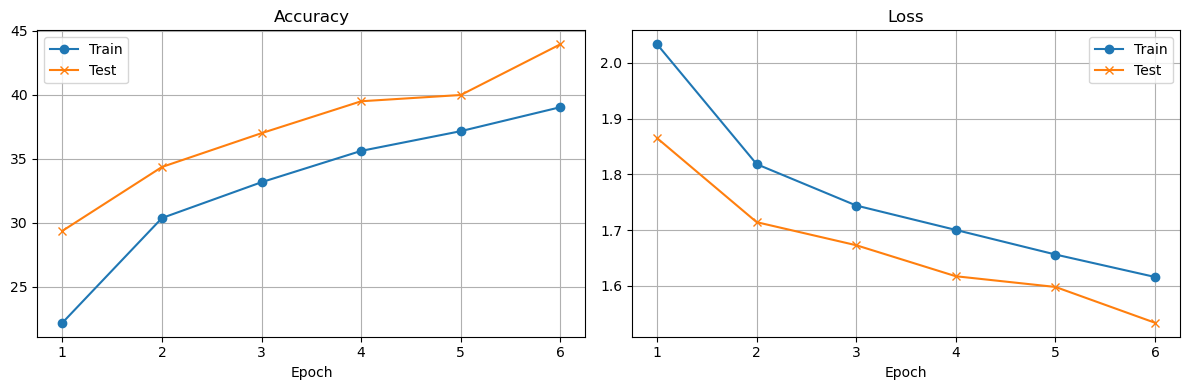

KeyboardInterrupt: 

In [8]:
train_and_plot_inline(model, train_loader, test_loader, train_data, test_data, device, epochs=50)
